In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTrain.csv
/kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTest.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

# Read Data

In [3]:
df = pd.read_csv("/kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTrain.csv")
df

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...,...
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000


# preprocessig

In [4]:
df['date'] = pd.to_datetime(df['date'])

In [5]:
df.set_index('date', inplace=True)

In [6]:
df = df.asfreq('D')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1462 entries, 2013-01-01 to 2017-01-01
Freq: D
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1462 non-null   float64
 1   humidity      1462 non-null   float64
 2   wind_speed    1462 non-null   float64
 3   meanpressure  1462 non-null   float64
dtypes: float64(4)
memory usage: 57.1 KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [10]:
df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


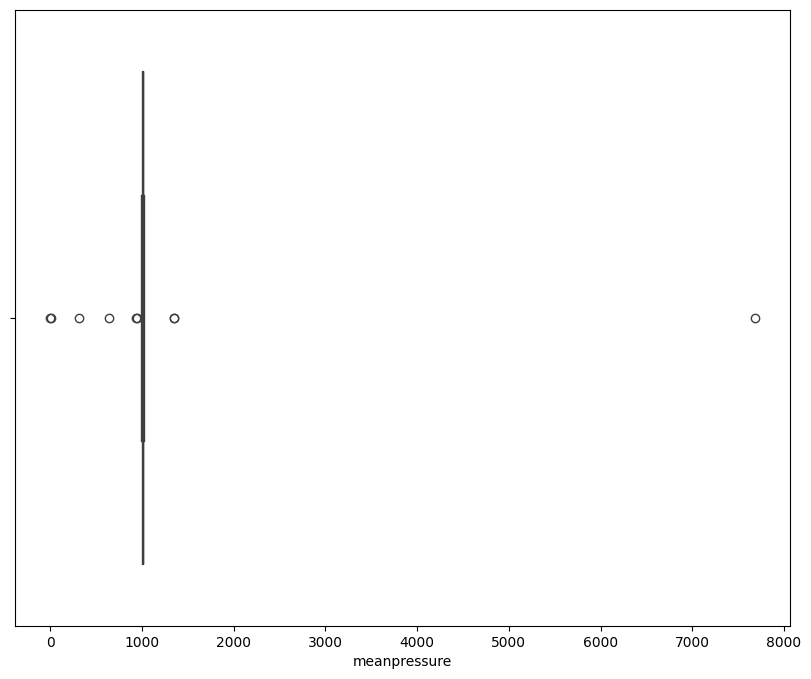

In [11]:
plt.figure(figsize=(10, 8))
sns.boxplot(df , x='meanpressure')
plt.show()

In [12]:
df[df['meanpressure'] > 3000]

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2016-03-28,25.933333,52.8,6.546667,7679.333333


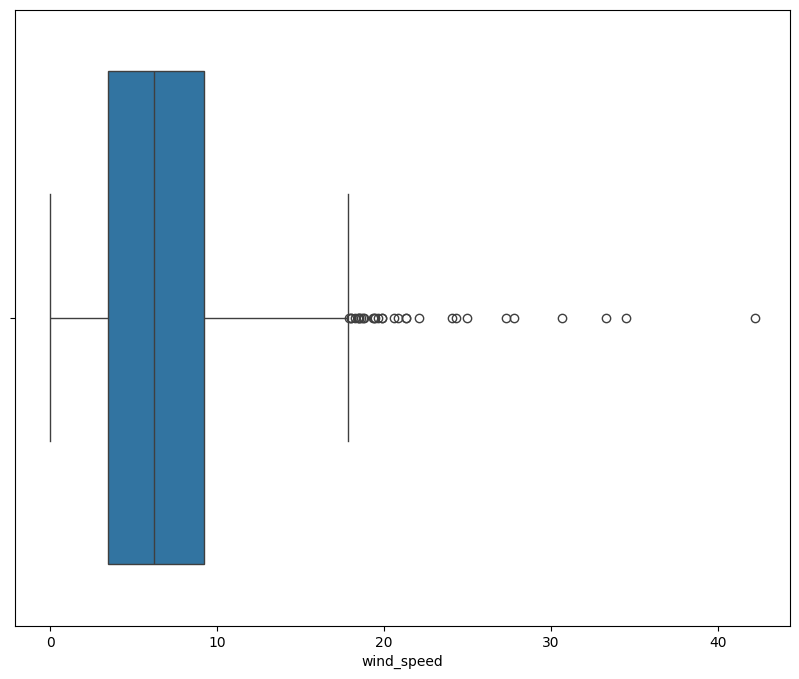

In [13]:
plt.figure(figsize=(10, 8))
sns.boxplot(df , x='wind_speed')
plt.show()

In [14]:
df[df['wind_speed'] > 30]

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-09-09,31.000000,57.500000,42.220000,1007.000000
2013-12-25,13.666667,63.166667,34.487500,1020.625000
2014-09-23,31.000000,47.000000,30.685714,1004.285714
2015-08-19,31.250000,61.250000,33.325000,1002.375000


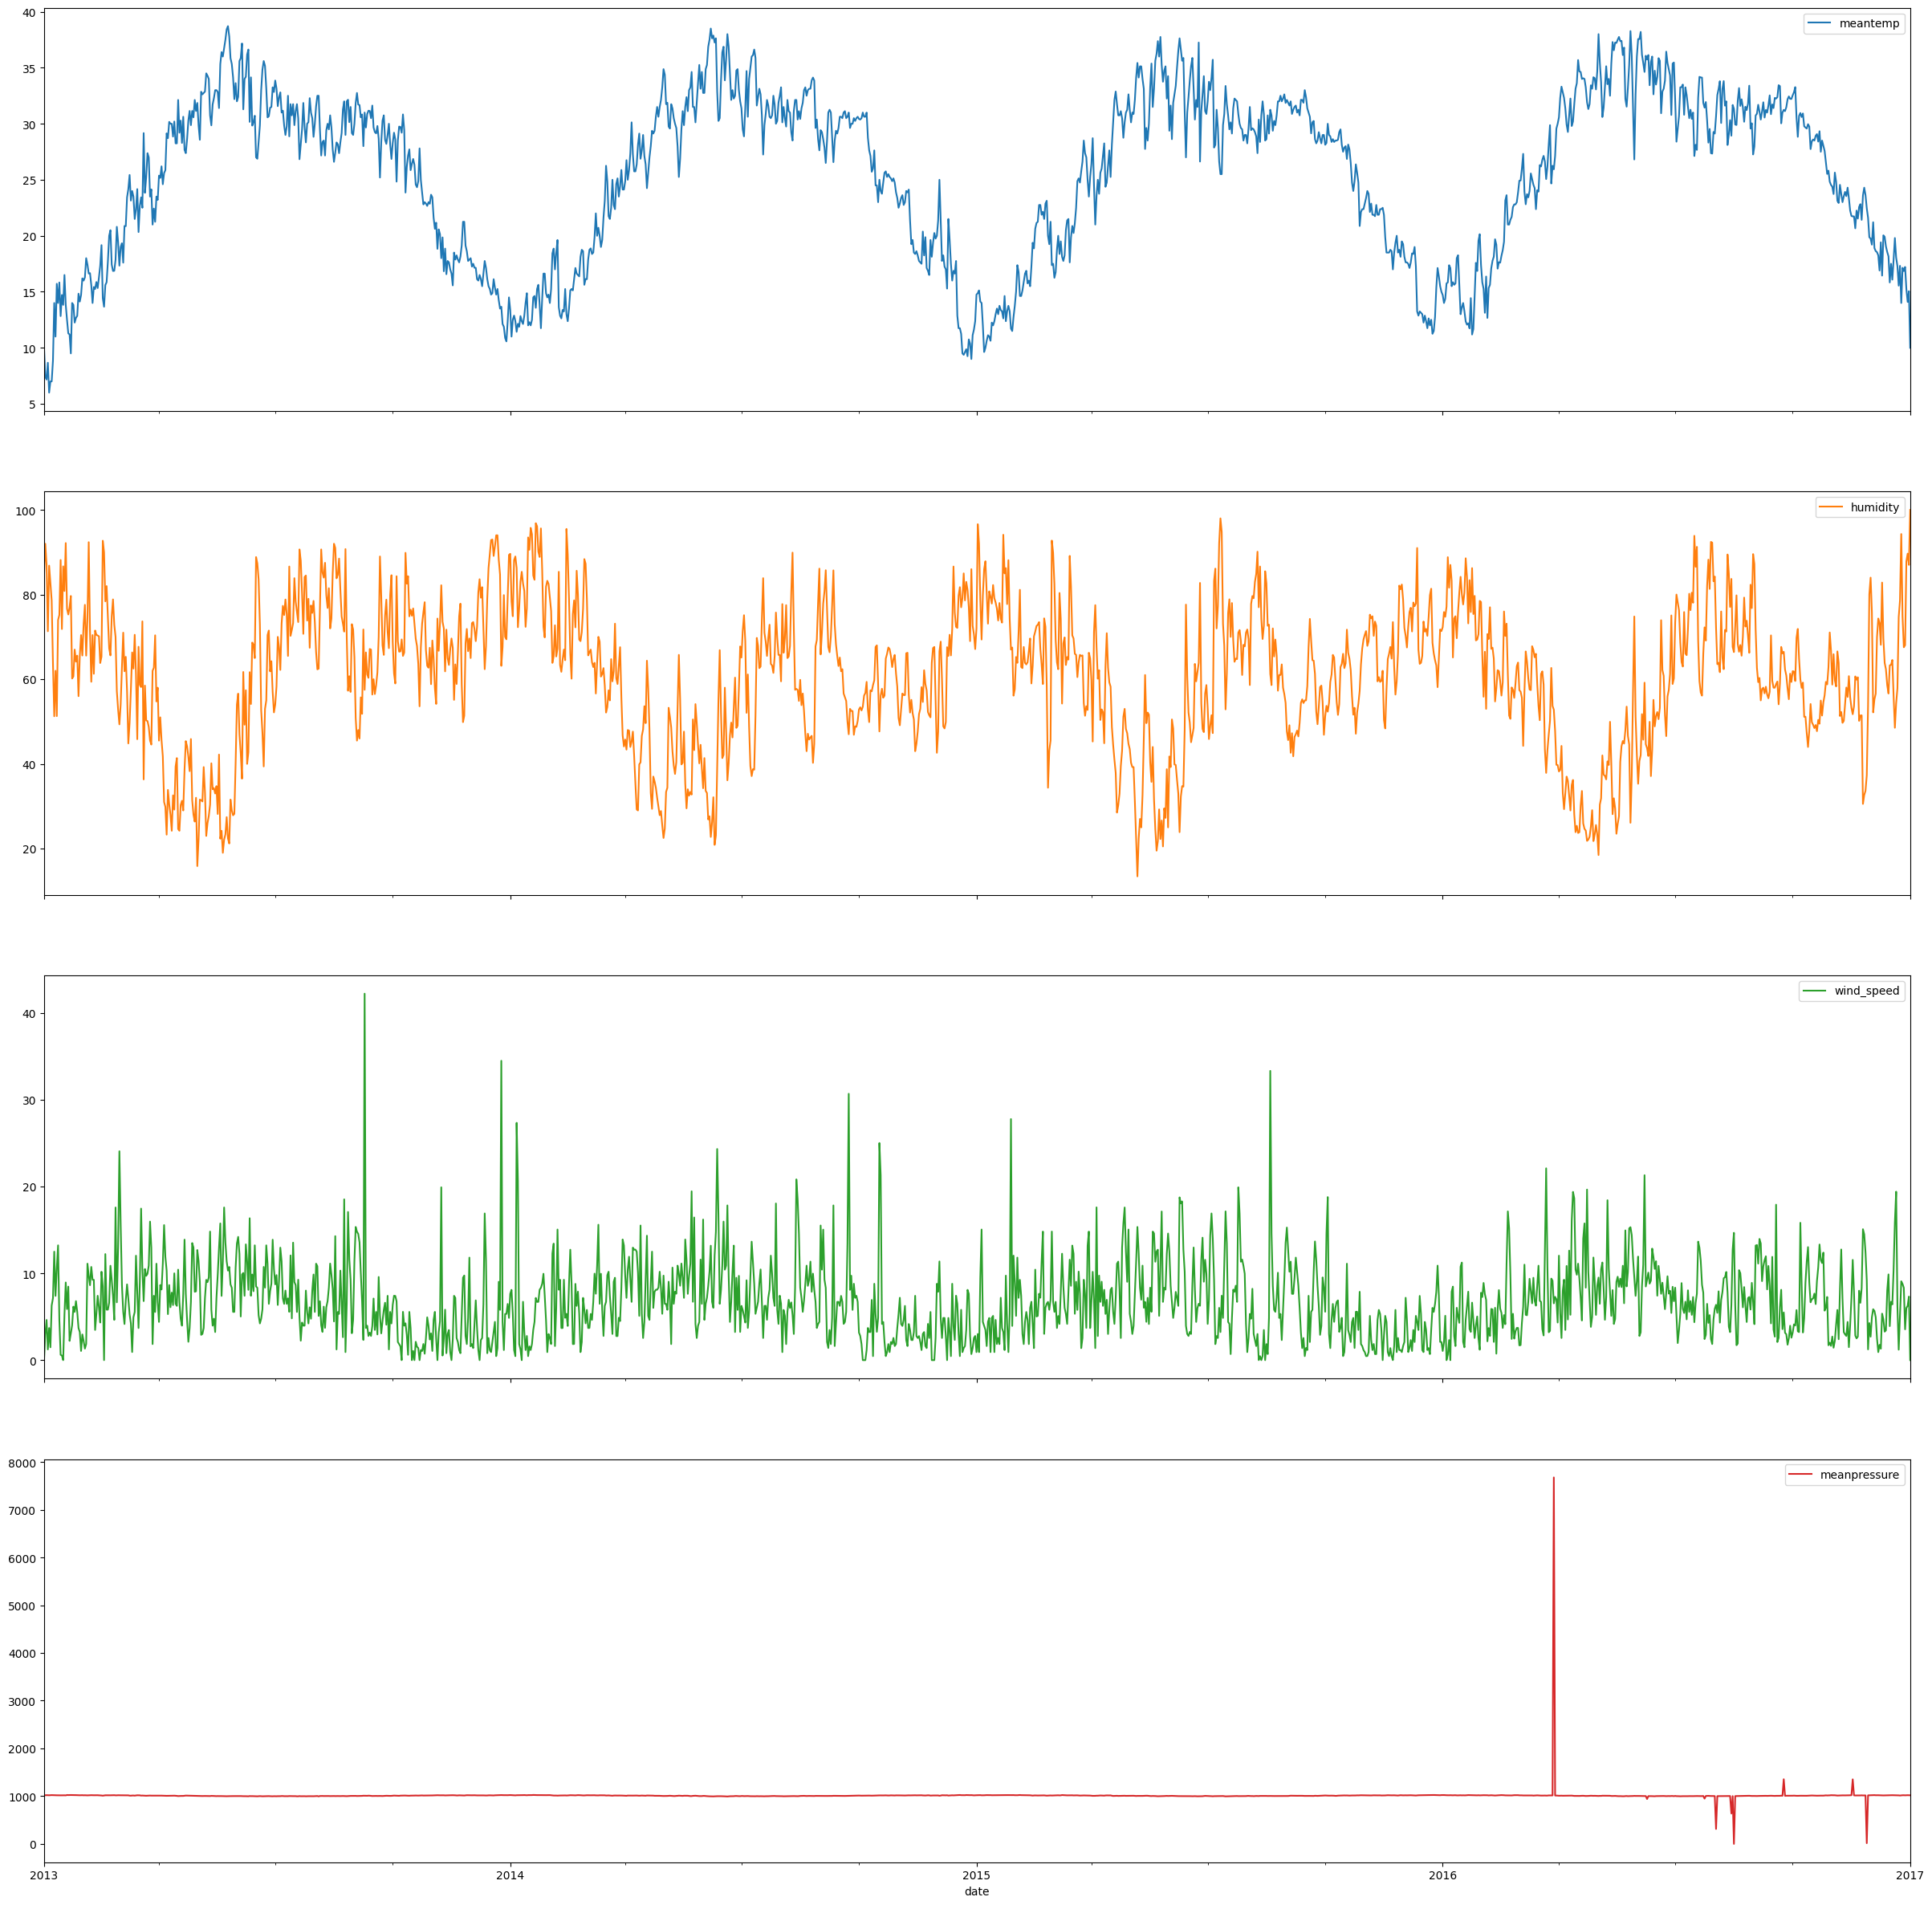

In [15]:
df.plot(subplots=True, figsize=(30,30))
plt.show()

In [16]:
ACCENT1 = '#00d4ff'
ACCENT2 = '#ff6b6b'
ACCENT3 = '#a8ff78'
ACCENT4 = '#ffd700'

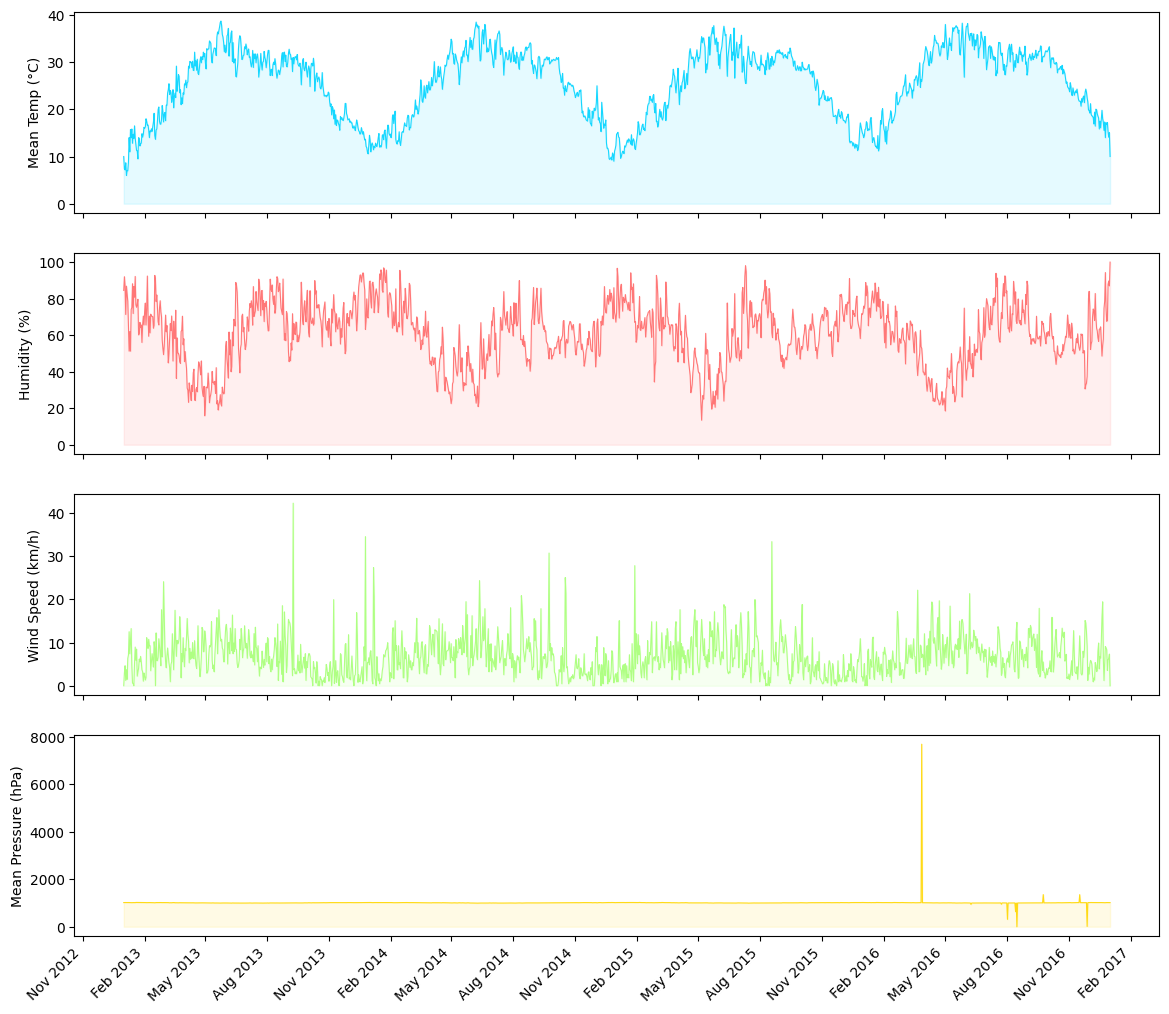

In [17]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

cols   = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
colors = [ACCENT1, ACCENT2, ACCENT3, ACCENT4]
labels = ['Mean Temp (°C)', 'Humidity (%)', 'Wind Speed (km/h)', 'Mean Pressure (hPa)']

for ax, col, color, label in zip(axes, cols, colors, labels):
    ax.plot(df.index, df[col], color=color, linewidth=0.8, alpha=0.9)
    ax.set_ylabel(label, fontsize=10)
    ax.fill_between(df.index, df[col], alpha=0.1, color=color)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.show()

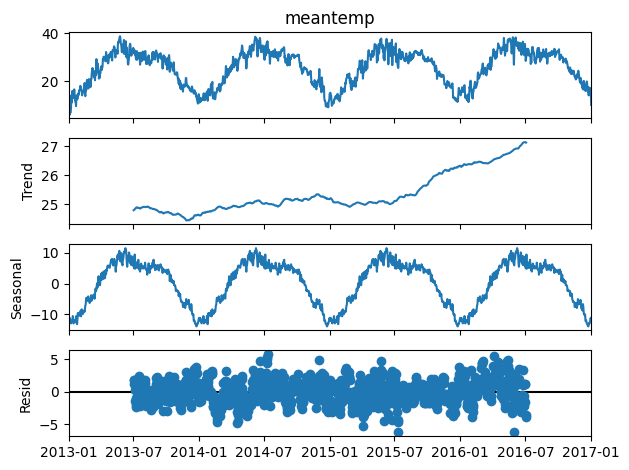

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['meantemp'], model='additive', period=365)
result.plot()
plt.show()

# Moving Averge 

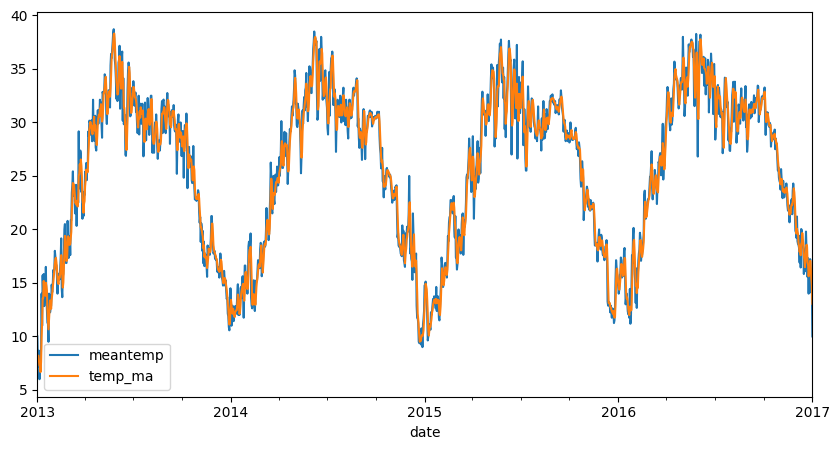

In [19]:
df['temp_ma'] = df['meantemp'].rolling(window=3).mean()

df[['meantemp','temp_ma']].plot(figsize=(10,5))
plt.show()

# Exponential Smoothing

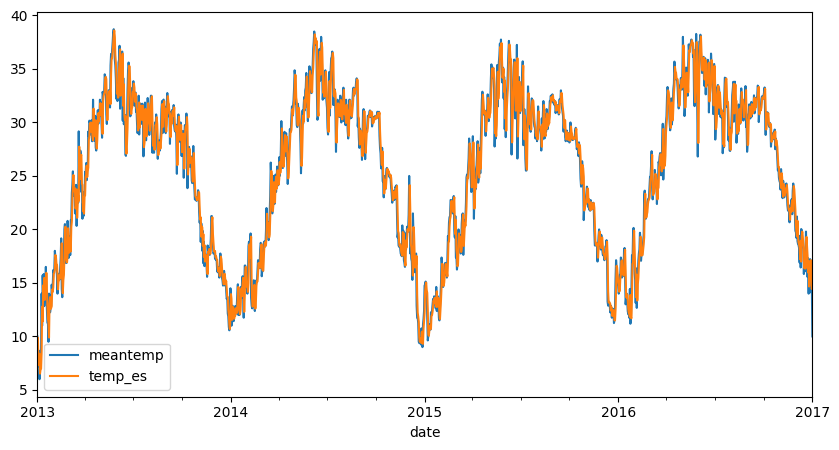

In [20]:
model = ExponentialSmoothing(df['meantemp'], trend='add')
fit = model.fit()

df['temp_es'] = fit.fittedvalues

df[['meantemp','temp_es']].plot(figsize=(10,5))
plt.show()

# ACF & PACF

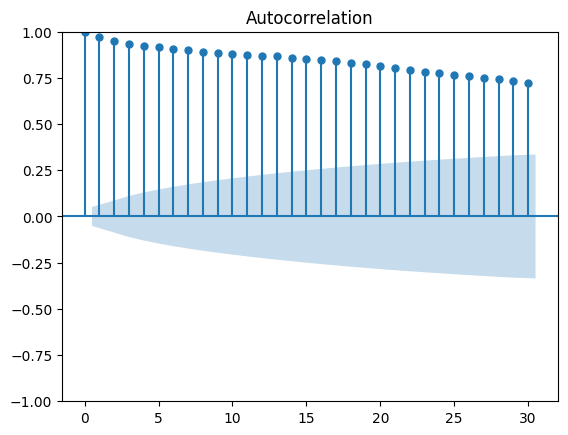

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['meantemp'], lags=30)
plt.show()

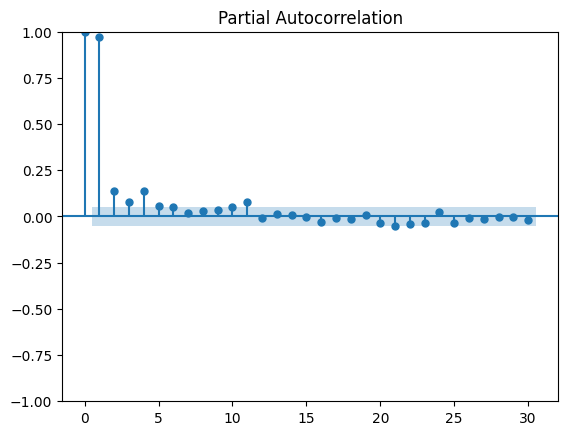

In [22]:
plot_pacf(df['meantemp'], lags=30)
plt.show()

# Build model 

In [23]:
train = df.iloc[:1200]
test = df.iloc[1200:]

In [24]:
model = ARIMA(
    train['meantemp'],
    order=(2,1,2),          # ARIMA part 
)

fit = model.fit()

In [25]:
print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:               meantemp   No. Observations:                 1200
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -2270.260
Date:                Fri, 05 Jun 2026   AIC                           4550.519
Time:                        04:06:29   BIC                           4575.966
Sample:                    01-01-2013   HQIC                          4560.105
                         - 04-14-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2210      0.238     -0.929      0.353      -0.687       0.245
ar.L2          0.4892      0.116      4.205      0.000       0.261       0.717
ma.L1         -0.0115      0.240     -0.048      0.9

In [26]:
forecast = fit.get_forecast(steps=len(test))
forcast_mean = forecast.predicted_mean
conf = forecast.conf_int()
conf

,lower meantemp,upper meantemp
2016-04-15,29.443889,35.743683
2016-04-16,28.387739,36.329017
2016-04-17,27.651060,36.650053
2016-04-18,27.225918,36.936753
2016-04-19,26.836530,37.153423
...,...,...
2016-12-28,7.229730,56.604406
2016-12-29,7.183186,56.650950
2016-12-30,7.136730,56.697406
2016-12-31,7.090361,56.743775


In [27]:
rmse = root_mean_squared_error(test['meantemp'], forcast_mean)
print("RMSE:", rmse)

RMSE: 6.460536924211833


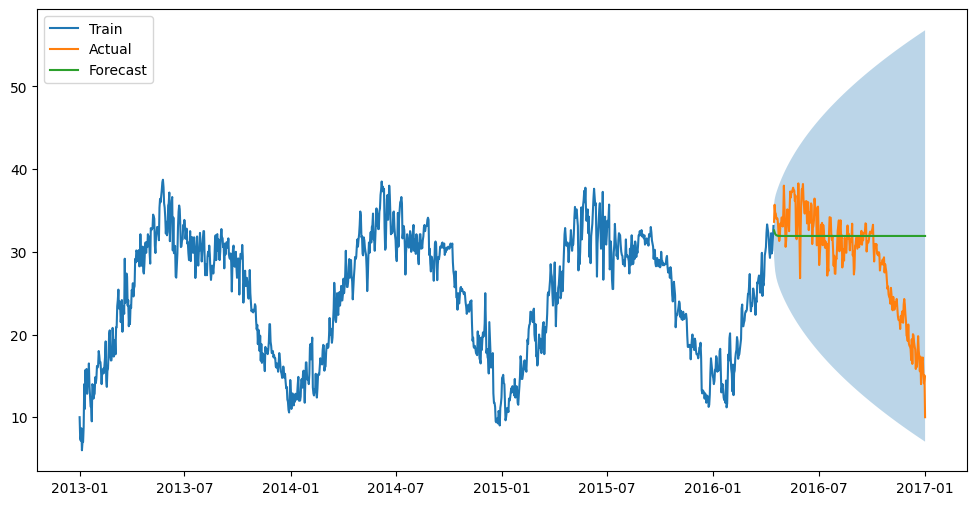

In [28]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train['meantemp'], label='Train')
plt.plot(test.index, test['meantemp'], label='Actual')
plt.plot(test.index, forcast_mean, label='Forecast')

plt.fill_between(
    test.index,
    conf.iloc[:,0],
    conf.iloc[:,1],
    alpha=0.3
)

plt.legend()
plt.show()